In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
import time, random
from tqdm.notebook import tqdm

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
batch_size = 128
lr = 1e-3
epochs = 20
input_size = 28*28
num_classes = 10
dropout_p = 0.2
data_root = "./data"

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_ds = torchvision.datasets.FashionMNIST(root=data_root, train=True, transform=transform, download=True)
test_ds  = torchvision.datasets.FashionMNIST(root=data_root, train=False, transform=transform, download=True)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Train samples:", len(train_ds), " Test samples:", len(test_ds))
print("Classes:", train_ds.classes)

100.0%
100.0%
100.0%
100.0%


Train samples: 60000  Test samples: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, n_classes, dropout=0.0):
        super().__init__()
        layers = []
        in_dim = input_dim
        for i, h in enumerate(hidden_layers):
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU(inplace=True))
            if dropout > 0:
                layers.append(nn.Dropout(p=dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

hidden_config = [512, 256, 128]
model = MLP(input_size, hidden_config, num_classes, dropout=dropout_p).to(device)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU(inplace=True)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU(inplace=True)
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [6]:
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [7]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in dataloader:
        images = images.to(device); labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss/total, correct/total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device); labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss/total, correct/total

In [8]:
train_losses, train_accs = [], []
test_losses, test_accs = [], []
start = time.time()

for epoch in range(1, epochs+1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc   = evaluate(model, test_loader, criterion, device)
    scheduler.step()   # optional
    train_losses.append(train_loss); train_accs.append(train_acc)
    test_losses.append(test_loss);   test_accs.append(test_acc)
    t1 = time.time()
    print(f"Epoch {epoch:02d} | Train loss: {train_loss:.4f} acc: {train_acc*100:.2f}% | "
          f"Test loss: {test_loss:.4f} acc: {test_acc*100:.2f}% | time: {t1-t0:.1f}s")

print("Total training time (s):", time.time() - start)

g:\My Drive\Sem 3\Deep Learning\DL Lab\venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | Train loss: 0.5316 acc: 80.55% | Test loss: 0.4196 acc: 84.08% | time: 81.2s
Epoch 02 | Train loss: 0.3864 acc: 86.02% | Test loss: 0.3887 acc: 86.25% | time: 76.8s
Epoch 03 | Train loss: 0.3521 acc: 87.12% | Test loss: 0.3570 acc: 86.87% | time: 76.2s
Epoch 04 | Train loss: 0.3282 acc: 88.00% | Test loss: 0.3413 acc: 87.51% | time: 78.8s
Epoch 05 | Train loss: 0.3092 acc: 88.51% | Test loss: 0.3492 acc: 87.15% | time: 79.4s
Epoch 06 | Train loss: 0.2949 acc: 89.14% | Test loss: 0.3337 acc: 87.84% | time: 84.0s
Epoch 07 | Train loss: 0.2836 acc: 89.48% | Test loss: 0.3419 acc: 87.88% | time: 80.1s
Epoch 08 | Train loss: 0.2733 acc: 89.80% | Test loss: 0.3269 acc: 88.21% | time: 82.8s
Epoch 09 | Train loss: 0.2603 acc: 90.32% | Test loss: 0.3377 acc: 87.98% | time: 98.4s
Epoch 10 | Train loss: 0.2551 acc: 90.50% | Test loss: 0.3350 acc: 88.53% | time: 81.9s
Epoch 11 | Train loss: 0.2207 acc: 91.79% | Test loss: 0.3125 acc: 89.45% | time: 81.0s
Epoch 12 | Train loss: 0.2068 ac

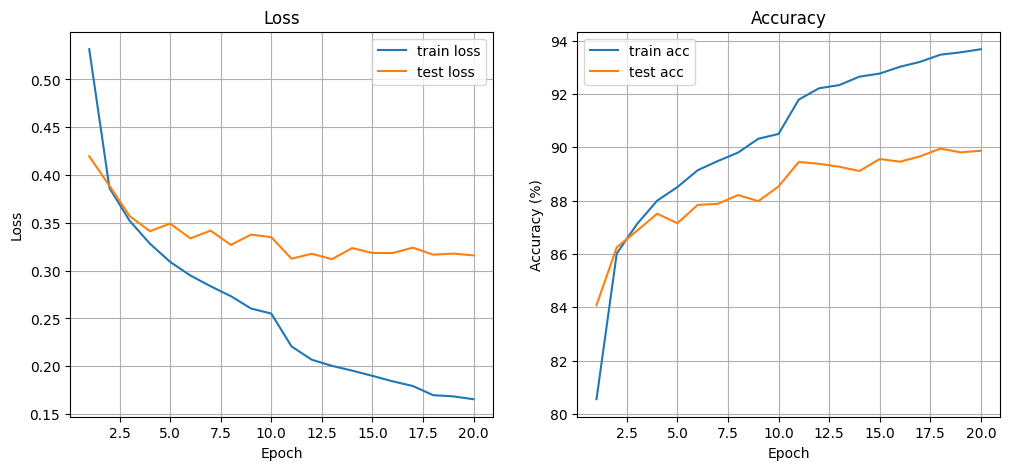

In [9]:
epochs_range = range(1, len(train_losses)+1)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label='train loss')
plt.plot(epochs_range, test_losses, label='test loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs_range, [a*100 for a in train_accs], label='train acc')
plt.plot(epochs_range, [a*100 for a in test_accs],  label='test acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('Accuracy'); plt.legend(); plt.grid(True)

plt.show()

Final test loss: 0.3159  test acc: 89.87%


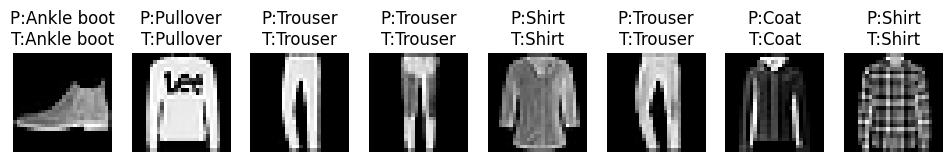

In [10]:
final_loss, final_acc = evaluate(model, test_loader, criterion, device)
print(f"Final test loss: {final_loss:.4f}  test acc: {final_acc*100:.2f}%")

classes = train_ds.classes
model.eval()
data_iter = iter(test_loader)
images, labels = next(data_iter)
images = images.to(device)
with torch.no_grad():
    logits = model(images)
    preds = logits.argmax(dim=1).cpu().numpy()

fig = plt.figure(figsize=(12,3))
for i in range(8):
    ax = fig.add_subplot(1,8,i+1)
    img = images[i].cpu().squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"P:{classes[preds[i]]}\nT:{classes[labels[i]]}")
    ax.axis('off')
plt.show()

In [11]:
def quick_test(hidden_sizes, small_epochs=6):
    tmp_model = MLP(input_size, hidden_sizes, num_classes, dropout=0.0).to(device)
    tmp_opt = optim.Adam(tmp_model.parameters(), lr=1e-3)
    for e in range(small_epochs):
        train_one_epoch(tmp_model, train_loader, criterion, tmp_opt, device)
    _, acc = evaluate(tmp_model, test_loader, criterion, device)
    return acc

configs = {
    '3x_large': [1024,512,256],
    '3x_med':   [512,256,128],
    '4x_small': [256,128,64,32]
}
for name, cfg in configs.items():
    acc = quick_test(cfg, small_epochs=4)
    print(f"{name} quick acc (4 ep): {acc*100:.2f}%")

3x_large quick acc (4 ep): 87.19%
3x_med quick acc (4 ep): 87.40%
4x_small quick acc (4 ep): 86.76%


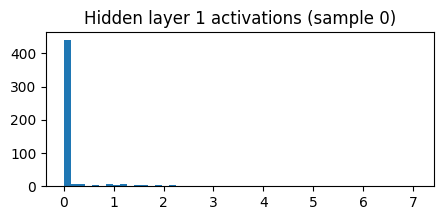

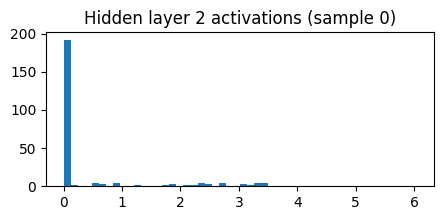

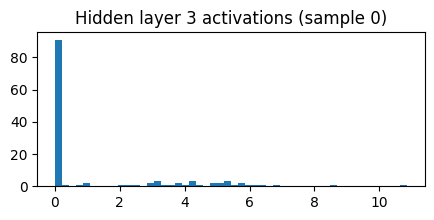

In [12]:
def get_activations(model, x_batch):
    acts = []
    current = x_batch.view(x_batch.size(0), -1)
    for layer in model.net:
        current = layer(current)
        if isinstance(layer, nn.ReLU) or isinstance(layer, nn.Tanh) or isinstance(layer, nn.LeakyReLU):
            acts.append(current.detach().cpu().numpy())
    return acts

images, labels = next(iter(test_loader))
images = images.to(device)[:8]
acts = get_activations(model, images)
for i, a in enumerate(acts):
    plt.figure(figsize=(5,2))
    plt.hist(a[0].ravel(), bins=50)
    plt.title(f"Hidden layer {i+1} activations (sample 0)")
    plt.show()

Most neurons are inactive (output = 0)
Only a small subset of neurons are active for this image

This is a sparse activation.

### Forward pass,Backward pass and Gradient updates

- **Forward pass:** Input images are flattened and passed through each linear layer. Each hidden layer applies a linear transform (weights * input + bias) followed by a non-linear activation (ReLU). The final layer produces raw scores (logits) for each class.

- **Loss computation:** CrossEntropyLoss accepts the logits and true labels and computes the negative log-likelihood after a softmax — this produces a scalar "loss" measuring how bad the predictions are.

- **Backward pass:** When `loss.backward()` is called, PyTorch computes gradients of the loss with respect to every weight using automatic differentiation (backpropagation). This traverses the computational graph from outputs back to inputs.

- **Gradient updates:** The optimizer (Adam or SGD) uses the computed gradients to update weights (e.g., `param -= lr * grad` for SGD). Adam uses adaptive learning rates and momentum terms to make updates more robust.

These three steps are repeated for many mini-batches and epochs so the model's weights progressively reduce the loss on the training data.

### Effect of hyperparameters

- **Learning rate (lr):** Larger lr speeds up learning but risks instability (loss bouncing). Smaller lr is stable but may need more epochs. Adam is more robust to lr choice than plain SGD.
- **Batch size:** Larger batches give better GPU utilization and more stable gradient estimates; small batches introduce noise which sometimes helps generalization but increases iteration overhead.
- **Number of epochs:** More epochs let the model converge; on small models diminishing returns appear. Monitor test accuracy to avoid overfitting.
- **Network depth/width:** More neurons and layers increase model capacity, usually improving accuracy if you have enough data and compute. Too large models on CPU slow training significantly and may overfit.